In [ ]:
# Customer Churn Logistical Regression Analysis

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from  matplotlib import pyplot as plt
import numpy as np

In [28]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [47]:
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

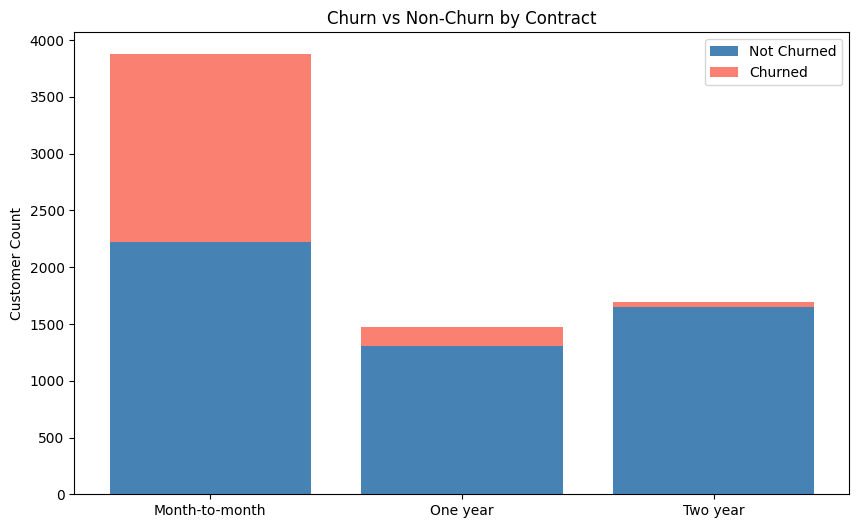

In [30]:
grouped = df.groupby(['Contract', 'Churn']).size().reset_index(name='count')

pivot = grouped.pivot(index='Contract', columns='Churn', values='count').fillna(0)

x = np.arange(len(pivot.index))
yes = pivot['Yes']
no = pivot['No']

plt.figure(figsize=(10,6))
plt.bar(x, no, label='Not Churned', color='steelblue')
plt.bar(x, yes, bottom=no, label='Churned', color='salmon')

plt.xticks(x, pivot.index)
plt.ylabel('Customer Count')
plt.title('Churn vs Non-Churn by Contract')
plt.legend()

plt.show()

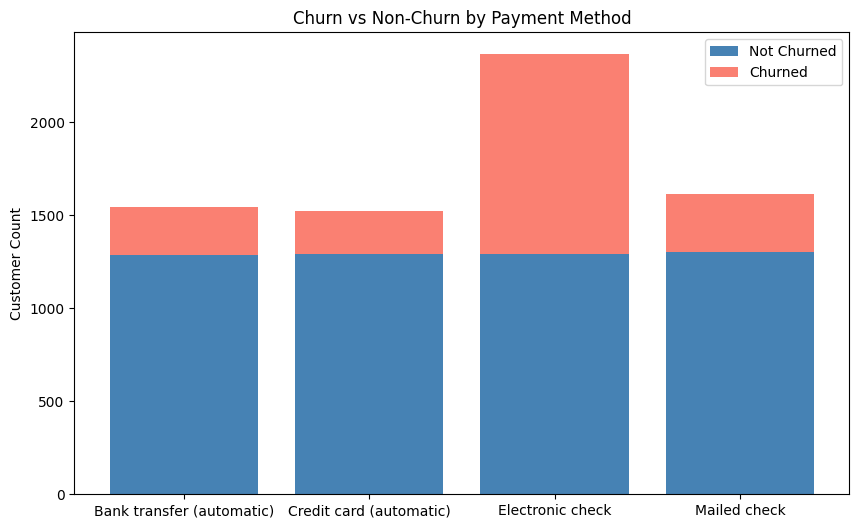

In [45]:
grouped = df.groupby(['PaymentMethod', 'Churn']).size().reset_index(name='count')

pivot = grouped.pivot(index='PaymentMethod', columns='Churn', values='count').fillna(0)

x = np.arange(len(pivot.index))
yes = pivot['Yes']
no = pivot['No']

plt.figure(figsize=(10,6))
plt.bar(x, no, label='Not Churned', color='steelblue')
plt.bar(x, yes, bottom=no, label='Churned', color='salmon')

plt.xticks(x, pivot.index)
plt.ylabel('Customer Count')
plt.title('Churn vs Non-Churn by Payment Method')
plt.legend()

plt.show()

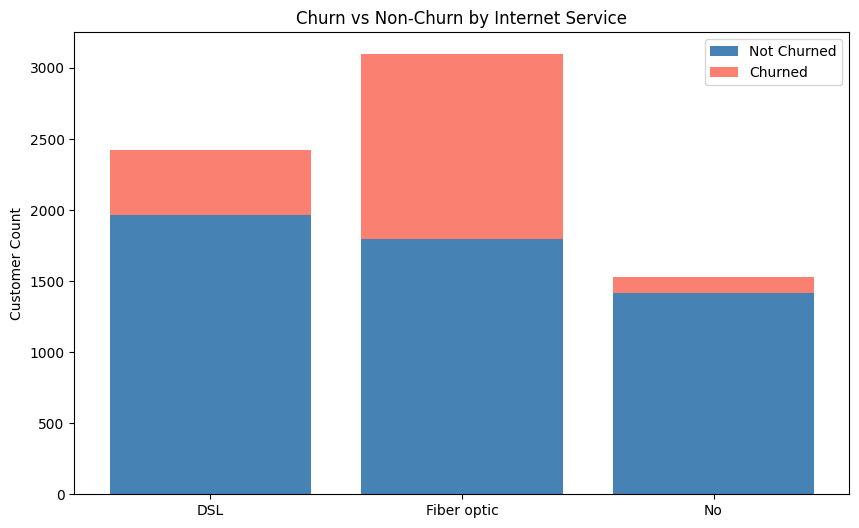

In [46]:
grouped = df.groupby(['InternetService', 'Churn']).size().reset_index(name='count')

pivot = grouped.pivot(index='InternetService', columns='Churn', values='count').fillna(0)

x = np.arange(len(pivot.index))
yes = pivot['Yes']
no = pivot['No']

plt.figure(figsize=(10,6))
plt.bar(x, no, label='Not Churned', color='steelblue')
plt.bar(x, yes, bottom=no, label='Churned', color='salmon')

plt.xticks(x, pivot.index)
plt.ylabel('Customer Count')
plt.title('Churn vs Non-Churn by Internet Service')
plt.legend()

plt.show()

In [21]:
# Convert churn boolean from Yes/No to 1/0
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [48]:
features = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "tenure"
]

X = pd.DataFrame()

# Numerical feature
X["tenure"] = df["tenure"]

# Contract
contract = pd.get_dummies(
df["Contract"],
prefix="Contract"
)

contract.drop(
columns=["Contract_Month-to-month"],
inplace=True
)

# Payment Method
payment = pd.get_dummies(
df["PaymentMethod"],
prefix="Payment"
)

payment.drop(
columns=["Payment_Electronic check"],
inplace=True
)

# Internet Service
internet = pd.get_dummies(
df["InternetService"],
prefix="Internet"
)

internet.drop(
columns=["Internet_Fiber optic"],
inplace=True
)

# Combine all feature groups
X = pd.concat(
[
X,
contract,
payment,
internet
],
axis=1
)

y = df["Churn"]

In [40]:
print(X)

      tenure  Contract_One year  Contract_Two year  \
0          1              False              False   
1         34               True              False   
2          2              False              False   
3         45               True              False   
4          2              False              False   
...      ...                ...                ...   
7038      24               True              False   
7039      72               True              False   
7040      11              False              False   
7041       4              False              False   
7042      66              False               True   

      Payment_Bank transfer (automatic)  Payment_Credit card (automatic)  \
0                                 False                            False   
1                                 False                            False   
2                                 False                            False   
3                                  True        

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 17
)

model = LogisticRegression(
    max_iter = 1000
)

model.fit(
    X_train,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [58]:
coefs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefs.sort_values(
    by = "Coefficient",
    ascending = False
)

,Feature,Coefficient
0,tenure,-0.028973
3,Payment_Bank transfer (automatic),-0.397737
5,Payment_Mailed check,-0.443046
4,Payment_Credit card (automatic),-0.478792
1,Contract_One year,-0.873308
6,Internet_DSL,-1.111636
2,Contract_Two year,-1.693043
7,Internet_No,-2.001141


In [59]:
'''
 - Based on these coefficients, churn is drastically reduced as the customer contracts increases from the baseline month-to-month to two years.
 - No internet customers and DSL cusstomers are less likely to churn than those who have fiber optic internet.
 - Every additional month of tenure
slightly reduces churn.
 - Payment methods outside of electronic check have lower churn trends.
'''

'\n - Based on these coefficients, churn is drastically reduced as the customer contracts increases from the baseline month-to-month to two years.\n - No internet customers and DSL cusstomers are less likely to churn than those who have fiber optic internet.\n - Every additional month of tenure\nslightly reduces churn.\n - Payment methods outside of electronic check have lower churn trends.\n'

In [60]:
y_pred = model.predict(X_test)
model.score(X_test, y_test)

0.7913413768630234

In [61]:
print(confusion_matrix(y_test, y_pred))

[[932  98]
 [196 183]]


In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1030
         Yes       0.65      0.48      0.55       379

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [ ]:
'''
Overall, the model does a much better job at identifying non-churners than churners. Since the goal is to correctly guess churners,
this would need more improvement to increase its accuracy metrics.
'''